# 01 · Reconstruction baseline development
**Four DIV2K development sources · 17 September 2026**

## tl;dr
This notebook tests whether tuning classical regularisation repairs Pilot 00's weak baseline,
then rechecks local operator sensitivity on 16 × 16 patches. Execution status is recorded in notebook metadata; running the cells produces the outputs below.
This is development evidence; no novel method, deep-learning result, calibrated uncertainty,
or independent test performance is claimed.

**Colab:** Run all. The setup mounts your Drive and uses the existing four source images.
Results and figures are written directly into a new dated Drive folder. Pilot 00 is preserved.
No GPU is required. The complete computational code is embedded here.

## Context & Methods
- 3 true Gaussian blur widths × 2 Gaussian noise levels × 2 processing conditions = 12 conditions per source.
- Nominal inverse blur is always 1.0 px. A separate oracle diagnostic receives the true blur width.
- Ridge: minimise ‖Ax−y‖² + λ‖x‖². Gradient regularisation: minimise ‖Ax−y‖² + λ(‖Dx x‖²+‖Dy x‖²), with periodic forward differences.
- The FFT solution uses H*/(|H|²+λP). Ridge P=1; gradient P=4[sin²(πfx)+sin²(πfy)]. Clipping the solved image to [0,1] is separate postprocessing.
- For each evaluated development source, choose one λ for each regulariser/information mode using only the other three sources, averaged across all 12 conditions. All variants of one source stay together. Choices are not made separately using each evaluated image's true blur severity.
- Keep the input and a prespecified 0.5 px Gaussian smoothing control. These are not deep-learning baselines.

### Key Assumptions
The same 512 × 512 native centre region and 32 px margin as Pilot 00 are used. Stored gamma-encoded RGB and periodic blur are controlled approximations, not calibrated camera physics. True blur and noise levels are simulation settings; only the oracle branch receives true blur. Common random noise is coupled across severities. JPEG means clipping + 8-bit rounding + quality-75 JPEG, without chroma subsampling.

**Four sources have already influenced project development.** Leaving each one out of λ selection prevents direct source reuse within that step but does not make these untouched test data. There is one noise realisation per source, not independent repetitions. The finite λ grid and severity range are engineering choices; boundary optima are flagged.

**Score limits:** operator spread uses blur widths 0.8/1.0/1.2 px and is not a posterior or confidence interval. Measurement-noise spread uses a prespecified 2/255 perturbation amplitude at fixed operator, regardless of the true noise level. It is an antithetic perturbation control, not a calibrated image-only uncertainty estimator. Each spread is based on three reconstructions (nominal plus two perturbations); residual and gradient are cheaper. A learned image-only uncertainty comparator and matched-budget model comparisons remain outstanding.

## Data
0801–0804 remain development-only. Embedded expected decoded-RGB hashes come from the repository's official-archive manifest at commit `e1f2471db5be4ca4b1ed006415d47a9db001c7fc`.
All crops and degraded versions inherit that role. No original images are included in the repository.

### 1. Imports and fixed configuration
Dependencies: numpy, pandas, matplotlib and Pillow. Colab normally provides these; locally install them before running.


In [1]:
"""Pilot 01: classical baseline development; no independent-test claims.

The notebook embeds these functions verbatim so Colab needs no repository install.
"""
import hashlib
import io
import json
import platform
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import PIL
from PIL import Image


CONFIG = {
    'source_ids': ['0801', '0802', '0803', '0804'],
    'seed': 20260917,
    'crop_size': 512,
    'context_border': 32,
    'true_sigmas': [1.2, 1.6, 2.0],
    'noise_stds': [2 / 255, 5 / 255],
    'nominal_sigma': 1.0,
    'lambdas': [0.00001, 0.0001, 0.0005, 0.002, 0.01, 0.05, 0.2],
    'families': ['ridge', 'gradient'],
    'scenarios': ['blur_noise', 'blur_noise_jpeg'],
    'jpeg_quality': 75,
    'jpeg_subsampling': 0,
    'smooth_sigma': 0.5,
    'patch_size': 16,
    'coverages': [0.5, 0.75, 0.9, 1.0],
    'operator_factors': [0.8, 1.0, 1.2],
    'noise_probe_std': 2 / 255,
    'role': 'development_only',
    'selection': 'leave-one-development-source-out; one lambda per family and operator-information mode across all conditions',
}




### 2. Locate the images and create a dated destination
Local runs can set `IMAGING01_DATA_DIR` and `IMAGING01_OUTPUT_DIR`. The output path must be new; existing runs are never overwritten.

In [2]:
import os
import sys
from datetime import datetime, timezone
from IPython.display import display, Markdown

get_ipython().run_line_magic('matplotlib', 'inline')
plt.ioff()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/reliable-reconstruction-under-mismatch')
else:
    PROJECT_DIR = Path.cwd()
    if PROJECT_DIR.name == 'notebooks':
        PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = Path(os.environ.get('IMAGING01_DATA_DIR', str(PROJECT_DIR / 'samples')))
timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
OUTPUT_DIR = Path(os.environ.get('IMAGING01_OUTPUT_DIR', str(PROJECT_DIR / 'results' / ('pilot_01_' + timestamp))))
assert DATA_DIR.is_dir(), f'Source folder does not exist: {DATA_DIR}'
print('Sources:', ', '.join(CONFIG['source_ids']))
print('Results will be saved in:', OUTPUT_DIR)
EXPECTED_RGB_HASHES = {'0801': 'c3b9ecc733b39ad48d0c260cbdc70e8cd08ed088ef9b82dc8d7dbc01b929d2e5', '0802': '320780296837730b43beebe107266e00779a0785ae3af52570e535d19165d682', '0803': '4ef27a27f8e05cd012a0389c28d55ef9377297b7c965024e5ad9b4bd4405c70d', '0804': 'c24a0821e1d8eaf46687e8803ec8dd75583d4f95b94dc79a50b42296e7c75296'}

No event loop hook running.
Sources: 0801, 0802, 0803, 0804
Results will be saved in: /workspace/scratch/7ff69f9960d0/reliable-reconstruction-under-mismatch/experiments/baseline_01/outputs/run_20260917


### 3. Define the data and inverse operators
Both inverse methods share the same forward operator and boundaries. Their regularisers differ.

In [3]:
def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()



def transfer(shape, sigma):
    fy = np.fft.fftfreq(shape[0])[:, None]
    fx = np.fft.fftfreq(shape[1])[None, :]
    return np.exp(-2 * np.pi**2 * sigma**2 * (fx**2 + fy**2))



def penalty(shape, family):
    if family == 'ridge':
        return np.ones(shape)
    if family == 'gradient':
        fy = np.fft.fftfreq(shape[0])[:, None]
        fx = np.fft.fftfreq(shape[1])[None, :]
        return 4 * (np.sin(np.pi * fx)**2 + np.sin(np.pi * fy)**2)
    raise ValueError(f'Unknown regulariser: {family}')



def apply(image, sigma):
    return np.fft.ifft2(np.fft.fft2(image, axes=(0, 1)) *
                       transfer(image.shape[:2], sigma)[..., None], axes=(0, 1)).real



def inverse_spectrum(spectrum, sigma, family, strength, clip=True):
    h = transfer(spectrum.shape[:2], sigma)
    filt = h / (h**2 + strength * penalty(spectrum.shape[:2], family))
    x = np.fft.ifft2(spectrum * filt[..., None], axes=(0, 1)).real
    return np.clip(x, 0, 1) if clip else x



def interior(x, config):
    b = config['context_border']
    return x[b:-b, b:-b] if b else x



def psnr(mse):
    return float(-10 * np.log10(mse)) if mse > 0 else float('inf')



def load_sources(data_dir, expected_hashes, config):
    records, sources, seen = [], {}, set()
    extent = config['crop_size'] + 2 * config['context_border']
    for sid in config['source_ids']:
        path = Path(data_dir) / (sid + '.png')
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            image.load()
            assert image.format == 'PNG' and image.mode in ('RGB', 'RGBA'), path.name
            if image.mode == 'RGBA':
                assert image.getchannel('A').getextrema() == (255, 255), 'Nonopaque alpha'
            width, height = image.size
            rgb = np.asarray(image.convert('RGB'))
        pixel_hash = hashlib.sha256(rgb.tobytes()).hexdigest()
        assert pixel_hash == expected_hashes[sid], f'Official decoded RGB mismatch: {sid}'
        assert pixel_hash not in seen, 'Duplicate source'
        seen.add(pixel_hash)
        assert min(width, height) >= extent
        left, top = (width - extent) // 2, (height - extent) // 2
        sources[sid] = rgb[top:top + extent, left:left + extent].astype(np.float64) / 255
        records.append(dict(source_id=sid, filename=path.name, sha256=sha256(path),
                            rgb_sha256=pixel_hash, width=width, height=height,
                            crop_left=left, crop_top=top, extent=extent, role='development_only'))
    return sources, pd.DataFrame(records)



def observations(reference, sid, config):
    identity = int(hashlib.sha256(sid.encode()).hexdigest()[:8], 16)
    rng = np.random.default_rng(np.random.SeedSequence([config['seed'], identity]))
    # Common random numbers couple severities; these are not independent noise repeats.
    z = rng.standard_normal(reference.shape)
    for true_sigma in config['true_sigmas']:
        blurred = apply(reference, true_sigma)
        for noise_std in config['noise_stds']:
            linear = blurred + noise_std * z
            quantised = np.rint(np.clip(linear, 0, 1) * 255).astype('uint8')
            stream = io.BytesIO()
            Image.fromarray(quantised).save(stream, format='JPEG',
                quality=config['jpeg_quality'], subsampling=config['jpeg_subsampling'], optimize=False)
            stream.seek(0)
            with Image.open(stream) as image:
                jpeg = np.asarray(image.convert('RGB'), dtype=np.float64) / 255
            for scenario, y in [('blur_noise', linear), ('blur_noise_jpeg', jpeg)]:
                if scenario in config['scenarios']:
                    yield dict(source_id=sid, true_sigma=true_sigma, noise_std=noise_std,
                               scenario=scenario), y


### 4. Define source-excluded tuning and patch evaluation
Risk is mean RGB squared error per 16 × 16 patch. Patches are ranked within each image. The textured stratum is the top quarter by clean-reference patch gradient: evaluation-only, unavailable to the deployed selector. It checks performance among informative regions; it is not a calibration guarantee.

In [4]:
def metric_row(meta, image, truth, model, info='none', strength=None, elapsed=None, **extra):
    mse = float(np.mean((image - truth)**2))
    return dict(**meta, model=model, operator_info=info, strength=strength,
                mse=mse, psnr_db=psnr(mse), inverse_seconds=elapsed, **extra)



def grid_search(sources, config):
    rows, controls = [], []
    for sid, reference in sources.items():
        truth = interior(reference, config)
        for meta, y in observations(reference, sid, config):
            spectrum = np.fft.fft2(y, axes=(0, 1))
            controls.append(metric_row(meta, interior(np.clip(y, 0, 1), config), truth, 'observed'))
            controls.append(metric_row(meta, interior(np.clip(apply(y, config['smooth_sigma']), 0, 1), config),
                                       truth, 'smooth_0.5px'))
            for info, sigma in [('nominal', config['nominal_sigma']), ('oracle_blur', meta['true_sigma'])]:
                for family in config['families']:
                    for strength in config['lambdas']:
                        tic = time.perf_counter()
                        estimate = inverse_spectrum(spectrum, sigma, family, strength)
                        elapsed = time.perf_counter() - tic
                        rows.append(metric_row(meta, interior(estimate, config), truth,
                                               family, info, strength, elapsed))
        print(f'Grid complete: {sid}', flush=True)
    return pd.DataFrame(rows), pd.DataFrame(controls)



def choose_source_excluded(grid, config):
    selections, chosen = [], []
    for sid in config['source_ids']:
        training = grid[grid.source_id != sid]
        for (family, info), frame in training.groupby(['model', 'operator_info']):
            # Equal source and condition weighting. Tie-break is ascending lambda.
            means = frame.groupby('strength').mse.mean().sort_index()
            strength = float(means.idxmin())
            used = sorted(frame.source_id.unique().tolist())
            assert sid not in used and len(used) == len(config['source_ids']) - 1
            selections.append(dict(excluded_source=sid, model=family, operator_info=info,
                selected_lambda=strength, tuning_sources=';'.join(used),
                tuning_mean_mse=float(means.loc[strength]),
                grid_boundary=bool(strength in (min(config['lambdas']), max(config['lambdas'])))))
            rows = grid[(grid.source_id == sid) & (grid.model == family) &
                        (grid.operator_info == info) & (grid.strength == strength)].copy()
            rows['tuning_sources'] = ';'.join(used)
            chosen.append(rows)
    return pd.DataFrame(selections), pd.concat(chosen, ignore_index=True)



def patch_mean(array, patch_size):
    h, w = array.shape
    assert h % patch_size == w % patch_size == 0
    return array.reshape(h // patch_size, patch_size, w // patch_size, patch_size).mean(axis=(1, 3))



def selected_risk(errors, scores, coverage, seed=82):
    errors, scores = np.asarray(errors).ravel(), np.asarray(scores).ravel()
    assert len(errors) == len(scores) > 0 and 0 < coverage <= 1
    order = np.lexsort((np.random.default_rng(seed).random(len(scores)), scores))
    count = int(np.ceil(coverage * len(scores)))
    return float(errors[order[:count]].mean())



def score_diagnostic(sources, selections, config):
    rows, examples = [], []
    for sid, reference in sources.items():
        truth = interior(reference, config)
        gy, gx = np.gradient(truth.mean(axis=-1))
        texture = patch_mean(np.hypot(gx, gy), config['patch_size']).ravel()
        # Reference-defined stratum is evaluation-only, never an operational score.
        textured = np.argsort(texture, kind='stable')[-int(np.ceil(len(texture) / 4)):]
        for meta, y in observations(reference, sid, config):
            spectrum = np.fft.fft2(y, axes=(0, 1))
            base = dict(reference=truth, observed=interior(np.clip(y, 0, 1), config))
            for family in config['families']:
                pick = selections[(selections.excluded_source == sid) &
                                  (selections.model == family) & (selections.operator_info == 'nominal')].iloc[0]
                strength = float(pick.selected_lambda)
                sigma = config['nominal_sigma']
                est = inverse_spectrum(spectrum, sigma, family, strength)
                operators = [inverse_spectrum(spectrum, sigma * f, family, strength)
                             for f in config['operator_factors']]
                key = f"noise_control:{sid}:{meta['true_sigma']}:{meta['noise_std']}"
                seed = int(hashlib.sha256(key.encode()).hexdigest()[:8], 16)
                # Fixed amplitude: the control does not receive true acquisition noise.
                noise = np.random.default_rng(seed).normal(0, config['noise_probe_std'], y.shape)
                noises = [inverse_spectrum(np.fft.fft2(y + s * noise, axes=(0, 1)),
                          sigma, family, strength) for s in (-1, 0, 1)]
                gy, gx = np.gradient(est.mean(axis=-1))
                scores = {
                    'operator_spread': np.sqrt(np.mean(np.var(operators, axis=0), axis=-1)),
                    'measurement_noise_spread': np.sqrt(np.mean(np.var(noises, axis=0), axis=-1)),
                    'measurement_residual': np.sqrt(np.mean((apply(est, sigma) - y)**2, axis=-1)),
                    'image_gradient': np.hypot(gx, gy),
                }
                errors = patch_mean(np.mean((interior(est, config) - truth)**2, axis=-1),
                                    config['patch_size']).ravel()
                mapped = {name: patch_mean(interior(score, config), config['patch_size']).ravel()
                          for name, score in scores.items()}
                for region, index in [('all', np.arange(len(errors))), ('textured_quartile', textured)]:
                    e = errors[index]
                    for coverage in config['coverages']:
                        oracle = selected_risk(e, e, coverage)
                        for name, score in mapped.items():
                            risk = selected_risk(e, score[index], coverage)
                            assert risk >= oracle - 1e-12
                            if coverage == 1:
                                assert np.isclose(risk, e.mean())
                            rows.append(dict(**meta, model=family, strength=strength, region=region,
                                score=name, coverage=coverage, retained_patches=int(np.ceil(coverage * len(e))),
                                available_patches=len(e), mse=risk))
                        for name, risk in [('random_expected', float(e.mean())), ('oracle_error', oracle)]:
                            rows.append(dict(**meta, model=family, strength=strength, region=region,
                                score=name, coverage=coverage, retained_patches=int(np.ceil(coverage * len(e))),
                                available_patches=len(e), mse=risk))
                base[family] = interior(est, config)
            if meta['true_sigma'] == 1.6 and meta['noise_std'] == 2 / 255 and meta['scenario'] == 'blur_noise':
                examples.append(dict(source_id=sid, **base))
        print(f'Patch diagnostics complete: {sid}', flush=True)
    return pd.DataFrame(rows), examples



def quality_summary(selected, controls):
    frame = pd.concat([selected, controls], ignore_index=True)
    result = frame.groupby(['scenario', 'model', 'operator_info'], as_index=False).agg(
        mean_mse=('mse', 'mean'), mean_image_psnr_db=('psnr_db', 'mean'),
        sources=('source_id', 'nunique'), rows=('mse', 'size'))
    result['pooled_psnr_db'] = result.mean_mse.map(psnr)
    return result


### 5. Validation and result saving
A tiny dense linear solve independently checks each FFT inverse. Constant-image checks expose ridge shrinkage and verify gradient-regulariser DC preservation. Input hashes, source exclusions, row counts, and risk endpoints are checked. Every saved output receives a SHA-256 entry.

In [5]:
def validate_math():
    """Independent dense solve on a tiny non-square grid, plus analytic DC checks."""
    shape = (5, 6)
    n = int(np.prod(shape))
    eye = np.eye(n)
    a = np.column_stack([apply(eye[:, j].reshape(*shape, 1), 1.3).ravel() for j in range(n)])
    d = []
    for axis in (0, 1):
        d.append(np.column_stack([(np.roll(eye[:, j].reshape(shape), -1, axis=axis) -
                                   eye[:, j].reshape(shape)).ravel() for j in range(n)]))
    rng = np.random.default_rng(71)
    y = rng.normal(size=(*shape, 1))
    errors = {}
    for family in ('ridge', 'gradient'):
        regulariser = np.eye(n) if family == 'ridge' else sum(x.T @ x for x in d)
        dense = np.linalg.solve(a.T @ a + 0.03 * regulariser, a.T @ y.ravel())
        fast = inverse_spectrum(np.fft.fft2(y, axes=(0, 1)), 1.3, family, 0.03, clip=False)
        errors[family] = float(np.max(np.abs(dense - fast.ravel())))
        assert errors[family] < 1e-10
    const = np.ones((*shape, 1))
    assert np.allclose(apply(const, 1.3), const)
    assert np.allclose(inverse_spectrum(np.fft.fft2(const, axes=(0, 1)), 1.3,
                                       'gradient', 0.03, clip=False), const)
    assert np.allclose(inverse_spectrum(np.fft.fft2(const, axes=(0, 1)), 1.3,
                                       'ridge', 0.03, clip=False), const / 1.03)
    assert np.isclose(psnr(0.01), 20)
    # Selection arithmetic, checked against a hand-computable example.
    assert np.isclose(selected_risk(np.array([.1, .4, .2, .3]),
                                    np.array([1, 4, 2, 3]), .5), .15)
    return dict(dense_solver_max_abs_error=errors, dc_checks=True, selection_check=True)



def plot_figures(grid, selected, controls, curves, examples, output_dir):
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
        'axes.spines.top': False, 'axes.spines.right': False, 'figure.facecolor': 'white'})
    colors = {'ridge': '#236A9B', 'gradient': '#C46F28'}
    figs = []
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
    for ax, scenario in zip(axes, ['blur_noise', 'blur_noise_jpeg']):
        for family in colors:
            series = grid[(grid.scenario == scenario) & (grid.operator_info == 'nominal') &
                          (grid.model == family)].groupby('strength').mse.mean()
            ax.plot(series.index, series * 1000, '-o', color=colors[family], label=family)
        baseline = controls[(controls.scenario == scenario) & (controls.model == 'observed')].mse.mean()
        ax.axhline(baseline * 1000, color='#555555', ls='--', label='degraded input')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_title('Blur + noise' if scenario == 'blur_noise' else 'Blur + noise + JPEG chain')
        ax.set_xlabel('Regularisation strength'); ax.grid(axis='y', alpha=.2)
    axes[0].set_ylabel('Mean RGB MSE (x 0.001)'); axes[1].legend(frameon=False)
    fig.suptitle('Development sweep | Nominal blur fixed at 1.0 px')
    fig.tight_layout(); fig.savefig(output_dir / 'regularisation_sweep.png', dpi=140); figs.append(fig)

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=True)
    for row, scenario in enumerate(['blur_noise', 'blur_noise_jpeg']):
        for col, info in enumerate(['nominal', 'oracle_blur']):
            ax = axes[row, col]
            for j, family in enumerate(colors):
                a = selected[(selected.scenario == scenario) & (selected.operator_info == info) &
                             (selected.model == family)].groupby('source_id').mse.mean()
                b = controls[(controls.scenario == scenario) & (controls.model == 'observed')].groupby('source_id').mse.mean()
                gain = 10 * np.log10(b / a)
                ax.plot(np.arange(len(gain)) + (j - .5) * .08, gain.values,
                        'o' if j == 0 else 's', color=colors[family], label=family)
            ax.axhline(0, ls='--', color='#555555'); ax.grid(axis='y', alpha=.2)
            ax.set_xticks(range(4), ['0801', '0802', '0803', '0804'])
            ax.set_title(('Linear' if row == 0 else 'JPEG chain') + ' | ' + info)
            if col == 0: ax.set_ylabel('PSNR gain over input (dB)')
    axes[0, 1].legend(frameon=False)
    fig.suptitle('Source-excluded tuning | Each point pools six conditions for one development source')
    fig.tight_layout(); fig.savefig(output_dir / 'source_excluded_gains.png', dpi=140); figs.append(fig)

    score_colors = {'operator_spread': '#236A9B', 'measurement_noise_spread': '#8B5C94',
                    'measurement_residual': '#C46F28', 'image_gradient': '#778839',
                    'random_expected': '#555555'}
    styles = ['-o', '--s', '-.^', ':D', '--']
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey='row')
    for row, region in enumerate(['all', 'textured_quartile']):
        for col, family in enumerate(['ridge', 'gradient']):
            ax = axes[row, col]
            # JPEG-only plot; complete tables preserve both scenarios.
            a = curves[(curves.region == region) & (curves.model == family) &
                       (curves.scenario == 'blur_noise_jpeg')]
            for (score, color), style in zip(score_colors.items(), styles):
                series = a[a.score == score].groupby('coverage').mse.mean()
                ax.plot(series.index * 100, series * 1000, style, color=color,
                        label=score.replace('_', ' '), markersize=4)
            ax.set_title(f'{family} | {region.replace("_", " ")}')
            ax.set_ylim(bottom=0); ax.grid(axis='y', alpha=.2)
            if row == 1: ax.set_xlabel('Patches retained within stratum (%)')
            if col == 0: ax.set_ylabel('Retained patch MSE (x 0.001)')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, fontsize=9)
    fig.suptitle('JPEG-chain patch selection | Development diagnostic; no calibration guarantee')
    fig.tight_layout(rect=(0, .09, 1, .96))
    fig.savefig(output_dir / 'patch_risk_coverage.png', dpi=140); figs.append(fig)

    fig, axes = plt.subplots(len(examples), 4, figsize=(11, 2.7 * len(examples)), squeeze=False)
    for row, example in enumerate(examples):
        for col, key in enumerate(['reference', 'observed', 'ridge', 'gradient']):
            axes[row, col].imshow(example[key]); axes[row, col].axis('off')
            axes[row, col].set_title(f'{example["source_id"]} | {key}')
    fig.suptitle('Anchor condition | True blur 1.6 px, noise 2/255; nominal inverse blur 1.0 px')
    fig.tight_layout(); fig.savefig(output_dir / 'reconstruction_examples.png', dpi=120); figs.append(fig)
    return figs



def save_results(result, output_dir):
    output_dir = Path(output_dir)
    for key in ['manifest', 'grid', 'controls', 'selections', 'selected', 'summary', 'curves']:
        result[key].to_csv(output_dir / f'{key}.csv', index=False)
    for key in ['config', 'checks', 'environment']:
        (output_dir / f'{key}.json').write_text(json.dumps(result[key], indent=2) + '\n')
    files = sorted(p for p in output_dir.iterdir() if p.is_file() and p.name != 'export_manifest.json')
    payload = {'experiment': 'pilot_01', 'role': 'development_only',
               'files': [dict(name=p.name, size_bytes=p.stat().st_size, sha256=sha256(p)) for p in files]}
    (output_dir / 'export_manifest.json').write_text(json.dumps(payload, indent=2) + '\n')
    assert all(sha256(output_dir / r['name']) == r['sha256'] for r in payload['files'])



def run(data_dir, output_dir, expected_hashes, config=None):
    config = json.loads(json.dumps(CONFIG if config is None else config))
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=False)
    assert Path(data_dir).resolve() != output_dir.resolve()
    checks = validate_math()
    tic = time.perf_counter()
    sources, manifest = load_sources(data_dir, expected_hashes, config)
    grid, controls = grid_search(sources, config)
    selections, selected = choose_source_excluded(grid, config)
    curves, examples = score_diagnostic(sources, selections, config)
    summary = quality_summary(selected, controls)
    n_obs = len(sources) * len(config['true_sigmas']) * len(config['noise_stds']) * len(config['scenarios'])
    assert len(grid) == n_obs * 2 * len(config['families']) * len(config['lambdas'])
    assert len(controls) == n_obs * 2
    assert len(selected) == n_obs * 2 * len(config['families'])
    for row in manifest.itertuples():
        assert sha256(Path(data_dir) / row.filename) == row.sha256
    # Anchor reproduction: original Pilot 00's fixed ridge setting and same source/noise identity.
    anchor = grid[(grid.true_sigma == 1.6) & (grid.noise_std == 2 / 255) &
                  (grid.model == 'ridge') & (grid.strength == .002)]
    checks.update(source_count=len(sources), observation_count=n_obs, grid_rows=len(grid),
        selected_inverse_rows=len(selected), control_rows=len(controls), patch_curve_rows=len(curves),
        input_hashes_unchanged=True, tuning_excludes_evaluated_source=True,
        source_role='development_only', elapsed_seconds=time.perf_counter() - tic,
        anchor_pooled_psnr={f'{a}_{b}': psnr(float(f.mse.mean()))
                           for (a, b), f in anchor.groupby(['scenario', 'operator_info'])})
    environment = dict(python=platform.python_version(), numpy=np.__version__, pandas=pd.__version__,
                       pillow=PIL.__version__, matplotlib=matplotlib.__version__, platform=platform.platform())
    result = dict(config=config, checks=checks, environment=environment, sources=sources,
                  manifest=manifest, grid=grid, controls=controls, selections=selections,
                  selected=selected, summary=summary, curves=curves, examples=examples)
    result['figures'] = plot_figures(grid, selected, controls, curves, examples, output_dir)
    for figure in result['figures']:
        plt.close(figure)
    save_results(result, output_dir)
    return result


### 6. Execute the development experiment
Progress is printed once per source and phase. This cell also creates all four figures and the result manifest.

In [6]:
result = run(DATA_DIR, OUTPUT_DIR, EXPECTED_RGB_HASHES, CONFIG)
print(json.dumps(result['checks'], indent=2))

Grid complete: 0801
Grid complete: 0802
Grid complete: 0803
Grid complete: 0804
Patch diagnostics complete: 0801
Patch diagnostics complete: 0802
Patch diagnostics complete: 0803
Patch diagnostics complete: 0804
{
  "dense_solver_max_abs_error": {
    "ridge": 3.1086244689504383e-15,
    "gradient": 1.2212453270876722e-15
  },
  "dc_checks": true,
  "selection_check": true,
  "source_count": 4,
  "observation_count": 48,
  "grid_rows": 1344,
  "selected_inverse_rows": 192,
  "control_rows": 96,
  "patch_curve_rows": 4608,
  "input_hashes_unchanged": true,
  "tuning_excludes_evaluated_source": true,
  "source_role": "development_only",
  "elapsed_seconds": 60.573657520999404,
  "anchor_pooled_psnr": {
    "blur_noise_nominal": 25.19469081134899,
    "blur_noise_oracle_blur": 29.10481276708939,
    "blur_noise_jpeg_nominal": 27.696821849084174,
    "blur_noise_jpeg_oracle_blur": 28.105475288120687
  }
}


<ipython-input-1-aaa7d9f10ef7>:129: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  frame = pd.concat([selected, controls], ignore_index=True)


## Results
### 7. Inspect quality and tuning choices
Pooled PSNR converts mean MSE to dB; mean image PSNR is a separate statistic. The oracle-blur branch is a diagnostic, including an incomplete model in the JPEG condition.

,scenario,model,operator_info,mean_mse,mean_image_psnr_db,sources,rows,pooled_psnr_db
0,blur_noise,gradient,nominal,0.00094,31.25842,4,24,30.28803
1,blur_noise,gradient,oracle_blur,0.00073,32.35607,4,24,31.35738
2,blur_noise,observed,none,0.00122,29.88808,4,24,29.14744
3,blur_noise,ridge,nominal,0.00175,27.93473,4,24,27.58056
4,blur_noise,ridge,oracle_blur,0.00120,30.09018,4,24,29.19237
5,blur_noise,smooth_0.5px,none,0.00113,30.29442,4,24,29.45780
6,blur_noise_jpeg,gradient,nominal,0.00097,31.01529,4,24,30.14819
7,blur_noise_jpeg,gradient,oracle_blur,0.00080,31.78188,4,24,30.94387
8,blur_noise_jpeg,observed,none,0.00111,30.34379,4,24,29.53298
9,blur_noise_jpeg,ridge,nominal,0.00167,28.10418,4,24,27.77939


,excluded_source,model,operator_info,selected_lambda,tuning_sources,tuning_mean_mse,grid_boundary
0,0801,gradient,nominal,0.05,0802;0803;0804,0.001097,False
1,0801,gradient,oracle_blur,0.05,0802;0803;0804,0.000895,False
2,0801,ridge,nominal,0.05,0802;0803;0804,0.001787,False
3,0801,ridge,oracle_blur,0.01,0802;0803;0804,0.001283,False
4,0802,gradient,nominal,0.05,0801;0803;0804,0.001050,False
5,0802,gradient,oracle_blur,0.05,0801;0803;0804,0.000843,False
6,0802,ridge,nominal,0.05,0801;0803;0804,0.001876,False
7,0802,ridge,oracle_blur,0.01,0801;0803;0804,0.001246,False
8,0803,gradient,nominal,0.05,0801;0802;0804,0.001036,False
9,0803,gradient,oracle_blur,0.05,0801;0802;0804,0.000857,False


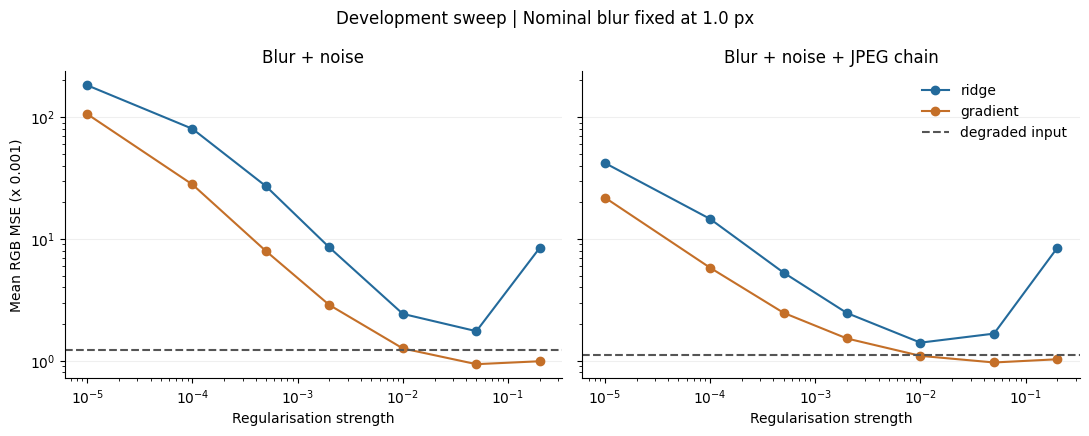

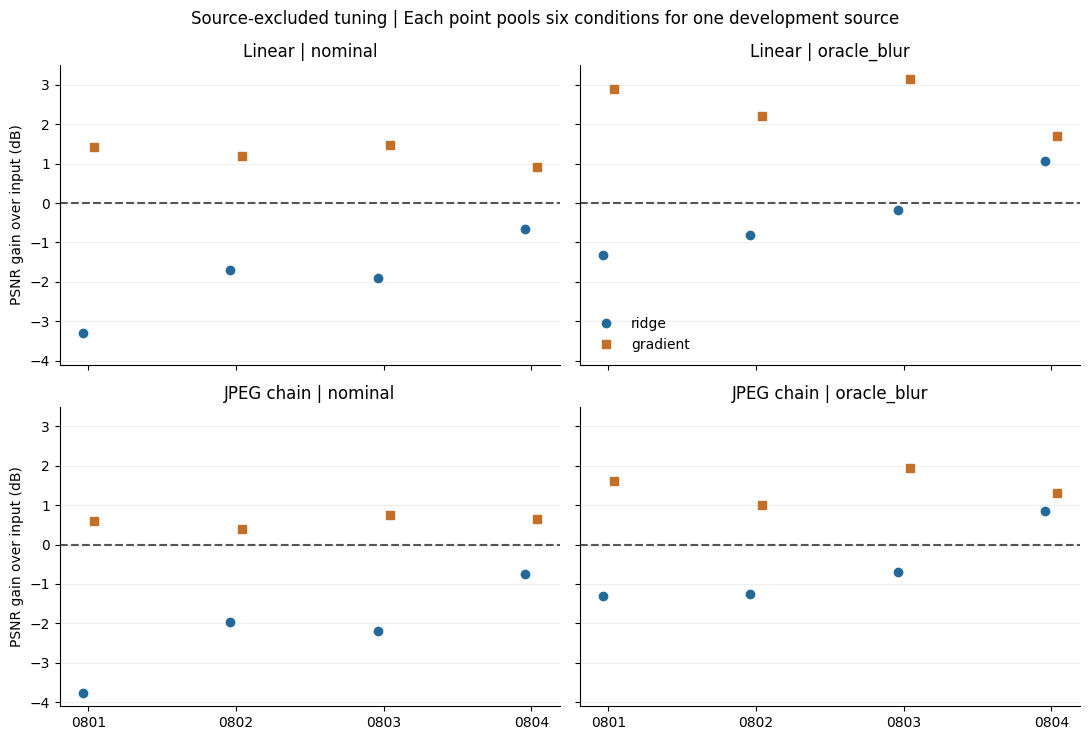

In [7]:
display(result['summary'].round(5))
display(result['selections'])
display(result['figures'][0])
display(result['figures'][1])

### 8. Recheck patch selection and images
The plot shows the JPEG-chain condition; `curves.csv` contains both conditions. Each curve weights the 24 source/condition combinations equally within a reconstruction family. The two classical regularisers are not substitutes for testing independent learned reconstruction families.

score                                       image_gradient  ...  random_expected
scenario        region            model                     ...                 
blur_noise      all               gradient        0.000425  ...         0.000936
                                  ridge           0.001304  ...         0.001746
                textured_quartile gradient        0.001888  ...         0.002208
                                  ridge           0.002535  ...         0.002939
blur_noise_jpeg all               gradient        0.000423  ...         0.000967
                                  ridge           0.001175  ...         0.001667
                textured_quartile gradient        0.001982  ...         0.002296
                                  ridge           0.002541  ...         0.002955

[8 rows x 6 columns]

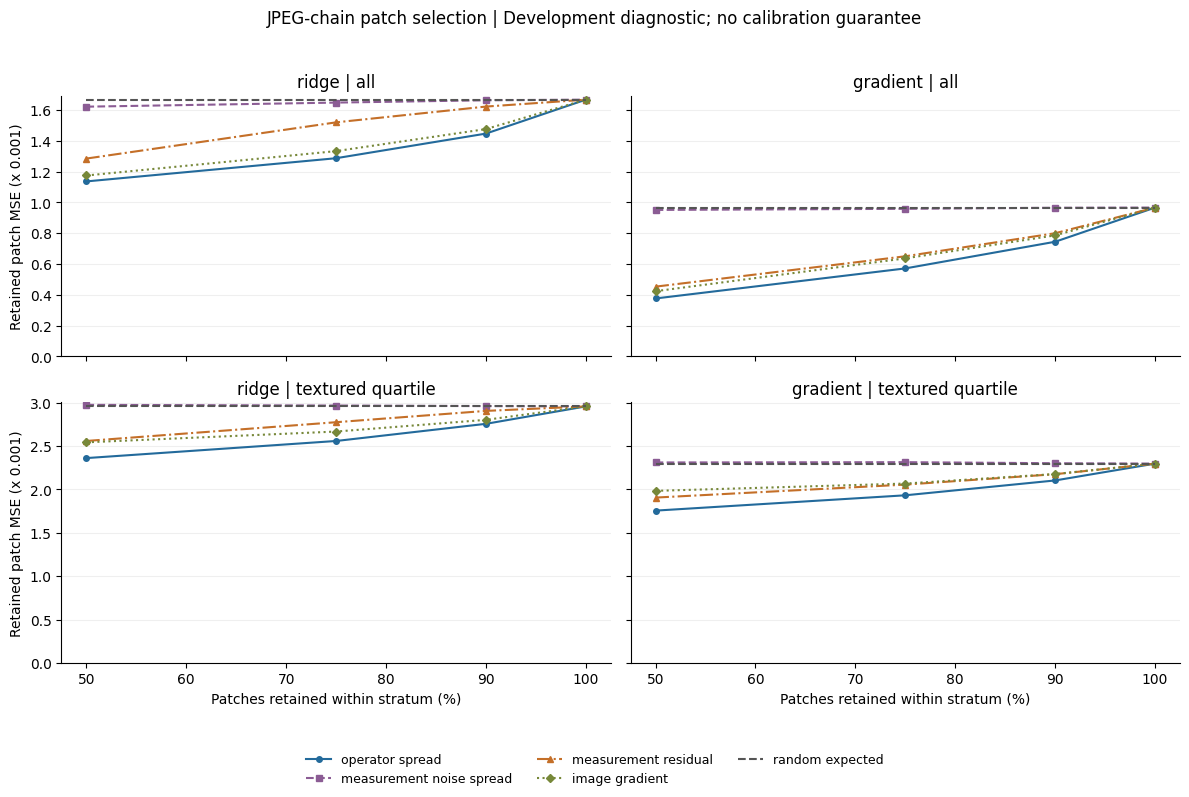

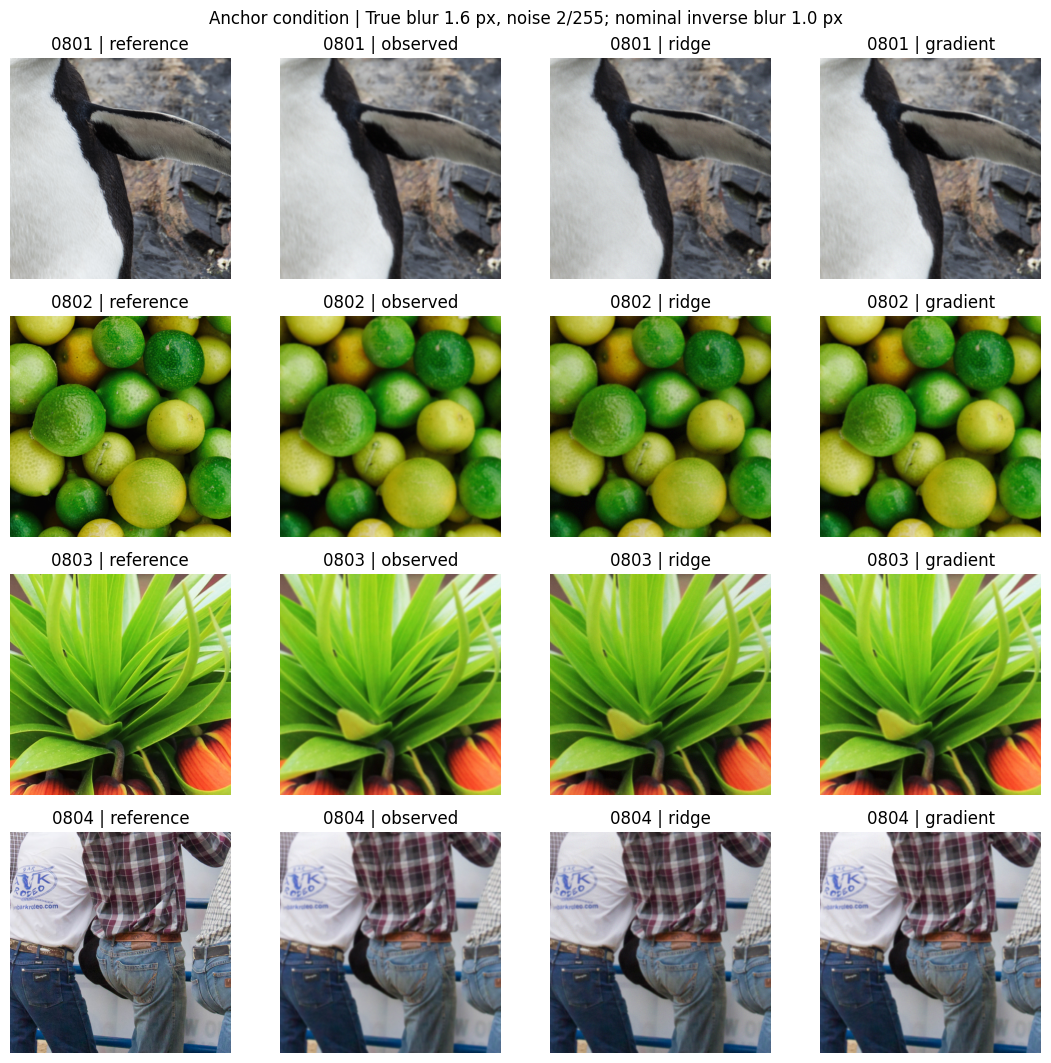

In [8]:
half = result['curves'].query('coverage == 0.5').groupby(['scenario','region','model','score']).mse.mean().unstack()
display(half.round(7))
display(result['figures'][2])
display(result['figures'][3])

## Takeaways
### 9. Read the computed decision summary
This summary uses saved results, not a promised outcome. It reports every family and both acquisition conditions.

In [9]:
s = result['summary']
for scenario in CONFIG['scenarios']:
    baseline_mse = float(s[(s.scenario == scenario) & (s.model == 'observed')].mean_mse.iloc[0])
    for family in CONFIG['families']:
        mse = float(s[(s.scenario == scenario) & (s.model == family) & (s.operator_info == 'nominal')].mean_mse.iloc[0])
        print(f'{scenario} | {family}: pooled PSNR gain over input = {10*np.log10(baseline_mse/mse):+.3f} dB')
for (scenario, region, family), values in half.iterrows():
    controls = values[['measurement_noise_spread','measurement_residual','image_gradient']]
    best = controls.idxmin()
    change = 100 * (1 - values.operator_spread / controls.min())
    print(f'{scenario} | {region} | {family}: operator spread vs best control ({best}) = {change:+.2f}% MSE reduction')
print('Boundary selections:', int(result['selections'].grid_boundary.sum()))
print('Development only. A positive entry is not a novelty, significance or calibration claim.')
print('Saved:', OUTPUT_DIR)


blur_noise | ridge: pooled PSNR gain over input = -1.567 dB
blur_noise | gradient: pooled PSNR gain over input = +1.141 dB
blur_noise_jpeg | ridge: pooled PSNR gain over input = -1.754 dB
blur_noise_jpeg | gradient: pooled PSNR gain over input = +0.615 dB
blur_noise | all | gradient: operator spread vs best control (image_gradient) = +9.94% MSE reduction
blur_noise | all | ridge: operator spread vs best control (image_gradient) = +1.05% MSE reduction
blur_noise | textured_quartile | gradient: operator spread vs best control (image_gradient) = +11.32% MSE reduction
blur_noise | textured_quartile | ridge: operator spread vs best control (image_gradient) = +4.18% MSE reduction
blur_noise_jpeg | all | gradient: operator spread vs best control (image_gradient) = +11.18% MSE reduction
blur_noise_jpeg | all | ridge: operator spread vs best control (image_gradient) = +3.27% MSE reduction
blur_noise_jpeg | textured_quartile | gradient: operator spread vs best control (measurement_residual) = +7

### What this can and cannot decide
A stronger classical baseline justifies moving to a verified pretrained reconstructor; it does not establish the proposed research contribution. A score advantage must survive useful coverage, informative-region checks, appropriate image-only uncertainty, matched information/compute, more than one learned family and source-disjoint calibration/testing.

If gains disappear against controls, redesign or stop the score rather than repeatedly tuning the same four sources. Read the unresolved direct competitor before making any definitive novelty claim. Full-reference MSE does not establish measurement support or hallucination detection.

The scoping review is a separate evidence-synthesis project. It may map what is already solved, conditional or untested even if this particular score fails. Its own added value over prior reviews and its formal methodology still require completion.

### Reproduction and sources
- [Pilot 00](https://github.com/Watchman77/reliable-reconstruction-under-mismatch/blob/main/notebooks/00_DIV2K_Operator_Mismatch_Pilot.ipynb)
- [Dataset and baseline audit](https://github.com/Watchman77/reliable-reconstruction-under-mismatch/blob/main/docs/dataset_and_baseline_audit_01.md)
- [Official DIV2K](https://data.vision.ee.ethz.ch/cvl/DIV2K/): academic research terms and original-image copyright apply.
- [Provisional gap synthesis](https://github.com/Watchman77/reliable-reconstruction-under-mismatch/blob/main/literature/synthesis/provisional_gap_synthesis_01.md)

The notebook is generated from `experiments/baseline_01/baseline.py`; its source hash is in notebook metadata. Software versions and output hashes are saved with each run. Rerunning in Colab is a separate environment check; this notebook never claims to have controlled your live Colab runtime.
